In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:

# 2. Install / Import Dependencies


import os
import json
import torch
import torchvision
import numpy as np
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Torch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Device: cuda


In [5]:

# 3. Paths


DATASET_ROOT = Path("/content/drive/MyDrive/dataset")

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

OUTPUT_DIR = Path("/content/drive/MyDrive/maskrcnn_phone_cover_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 2  # background + Phone_Cover

In [6]:

# 4. COCO Dataset Class


class CocoMaskDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.image_dir = self.root_dir / "images"
        self.annotation_path = self.root_dir / "annotations.json"

        with open(self.annotation_path, "r") as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]
        self.annotations = self.coco["annotations"]

        self.image_id_to_annotations = {}
        for ann in self.annotations:
            self.image_id_to_annotations.setdefault(ann["image_id"], []).append(ann)

    def __len__(self):
        return len(self.images)

    def polygon_to_mask(self, polygons, height, width):
        import cv2

        mask = np.zeros((height, width), dtype=np.uint8)

        for polygon in polygons:
            pts = np.array(polygon, dtype=np.int32).reshape(-1, 2)
            cv2.fillPoly(mask, [pts], 1)

        return mask

    def __getitem__(self, idx):
        image_info = self.images[idx]
        image_id = image_info["id"]
        file_name = image_info["file_name"]

        image_path = self.image_dir / file_name
        image = Image.open(image_path).convert("RGB")

        width, height = image.size
        anns = self.image_id_to_annotations.get(image_id, [])

        boxes = []
        labels = []
        masks = []
        areas = []
        iscrowd = []

        for ann in anns:
            if "segmentation" not in ann or len(ann["segmentation"]) == 0:
                continue

            x, y, w, h = ann["bbox"]

            if w <= 0 or h <= 0:
                continue

            boxes.append([x, y, x + w, y + h])
            labels.append(1)  # Phone_Cover class
            masks.append(self.polygon_to_mask(ann["segmentation"], height, width))
            areas.append(ann.get("area", w * h))
            iscrowd.append(ann.get("iscrowd", 0))

        image = F.to_tensor(image)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            masks = torch.zeros((0, height, width), dtype=torch.uint8)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([image_id]),
            "area": areas,
            "iscrowd": iscrowd,
        }

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))

In [7]:

# 5. Dataloaders


train_dataset = CocoMaskDataset(TRAIN_DIR)
val_dataset = CocoMaskDataset(VAL_DIR)
test_dataset = CocoMaskDataset(TEST_DIR)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 62
Val: 19
Test: 9


In [8]:
# ============================================================
# 6. Model
# ============================================================

def get_model(num_classes):
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes
    )

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256

    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model


model = get_model(NUM_CLASSES)
model.to(device)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 197MB/s]


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [9]:

# 7. Optimizer and Scheduler


params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

NUM_EPOCHS = 15

In [10]:

# 8. Training and Validation Loop


def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()

    total_loss = 0.0

    for batch_idx, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if batch_idx % 10 == 0:
            print(
                f"Epoch [{epoch}] "
                f"Batch [{batch_idx}/{len(data_loader)}] "
                f"Loss: {losses.item():.4f}"
            )

    return total_loss / len(data_loader)


@torch.no_grad()
def validate_loss(model, data_loader, device):
    model.train()

    total_loss = 0.0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        total_loss += losses.item()

    return total_loss / len(data_loader)


history = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)
    val_loss = validate_loss(model, val_loader, device)

    lr_scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print("=" * 60)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print("=" * 60)

    checkpoint_path = OUTPUT_DIR / f"maskrcnn_epoch_{epoch}.pth"
    torch.save(model.state_dict(), checkpoint_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_path = OUTPUT_DIR / "maskrcnn_best.pth"
        torch.save(model.state_dict(), best_path)
        print("Saved best model:", best_path)

Epoch [1] Batch [0/31] Loss: 4.0909
Epoch [1] Batch [10/31] Loss: 0.2746
Epoch [1] Batch [20/31] Loss: 0.7919
Epoch [1] Batch [30/31] Loss: 0.8824
Epoch 1/15
Train Loss: 0.9400
Val Loss:   0.8159
Saved best model: /content/drive/MyDrive/maskrcnn_phone_cover_outputs/maskrcnn_best.pth
Epoch [2] Batch [0/31] Loss: 0.7722
Epoch [2] Batch [10/31] Loss: 0.4401
Epoch [2] Batch [20/31] Loss: 0.4296
Epoch [2] Batch [30/31] Loss: 0.2694
Epoch 2/15
Train Loss: 0.4741
Val Loss:   0.2579
Saved best model: /content/drive/MyDrive/maskrcnn_phone_cover_outputs/maskrcnn_best.pth
Epoch [3] Batch [0/31] Loss: 0.3726
Epoch [3] Batch [10/31] Loss: 0.2433
Epoch [3] Batch [20/31] Loss: 0.1462
Epoch [3] Batch [30/31] Loss: 0.2863
Epoch 3/15
Train Loss: 0.1963
Val Loss:   0.1421
Saved best model: /content/drive/MyDrive/maskrcnn_phone_cover_outputs/maskrcnn_best.pth
Epoch [4] Batch [0/31] Loss: 0.1949
Epoch [4] Batch [10/31] Loss: 0.2267
Epoch [4] Batch [20/31] Loss: 0.5925
Epoch [4] Batch [30/31] Loss: 0.1642
E

In [11]:

# 9. Save Training History

history_path = OUTPUT_DIR / "training_history.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("Saved:", history_path)

Saved: /content/drive/MyDrive/maskrcnn_phone_cover_outputs/training_history.json


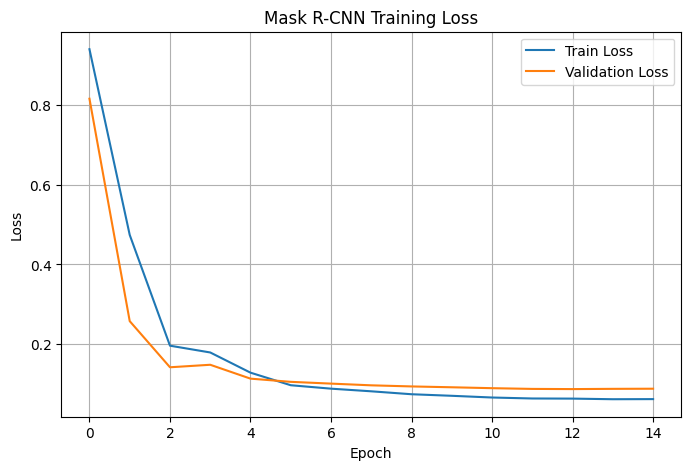

Saved: /content/drive/MyDrive/maskrcnn_phone_cover_outputs/loss_curve.png


In [12]:

# 10. Plot Loss Curves

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Mask R-CNN Training Loss")
plt.legend()
plt.grid(True)

loss_plot_path = OUTPUT_DIR / "loss_curve.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()

print("Saved:", loss_plot_path)

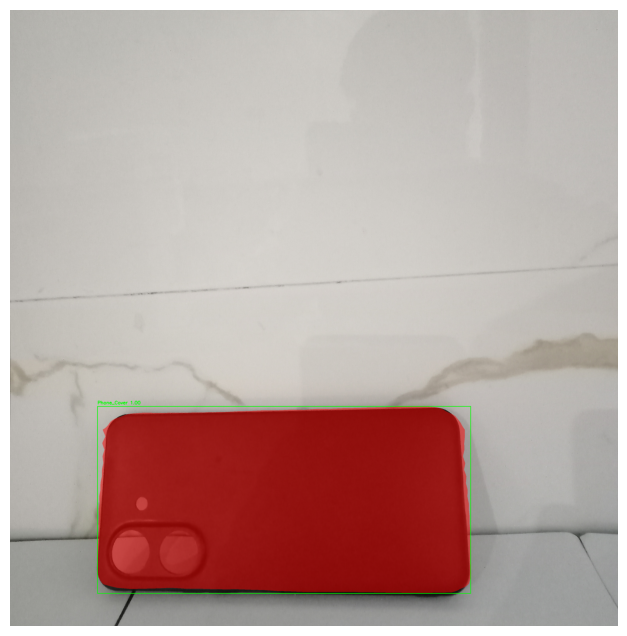

In [ ]:

# 11. Inference Visualization


import cv2
import matplotlib.pyplot as plt

model.eval()

def visualize_prediction(dataset, index=0, threshold=0.5):
    image, target = dataset[index]

    with torch.no_grad():
        prediction = model([image.to(device)])[0]

    image_np = image.permute(1, 2, 0).cpu().numpy()
    image_np = (image_np * 255).astype(np.uint8).copy()

    for i, score in enumerate(prediction["scores"].detach().cpu().numpy()):
        if score < threshold:
            continue

        mask = prediction["masks"][i, 0].detach().cpu().numpy()
        mask = mask > 0.5

        box = prediction["boxes"][i].detach().cpu().numpy().astype(int)

        image_np[mask] = image_np[mask] * 0.5 + np.array([255, 0, 0]) * 0.5

        cv2.rectangle(
            image_np,
            (box[0], box[1]),
            (box[2], box[3]),
            (0, 255, 0),
            2
        )

        cv2.putText(
            image_np,
            f"Phone_Cover {score:.2f}",
            (box[0], max(box[1] - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    plt.figure(figsize=(8, 8))
    plt.imshow(image_np)
    plt.axis("off")
    plt.show()


visualize_prediction(test_dataset, index=2, threshold=0.5)

In [20]:

# 12. Save Final Model

final_model_path = OUTPUT_DIR / "maskrcnn.pth"
torch.save(model.state_dict(), final_model_path)

print("Final model saved:", final_model_path)

Final model saved: /content/drive/MyDrive/maskrcnn_phone_cover_outputs/maskrcnn.pth
